# Proyecto: Minería de Datos - Sistemas de Recomendación con MovieLens 20M
## Minería de Patrones y Similitud con Spark, MinHashing y LSH

---

## SETUP INICIAL: Configuración de Spark y Importaciones

### Paso 1: Configurar la sesión de Spark


In [1]:
# Importaciones de Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.linalg import Vectors

# Importaciones cientificas y visualizacion
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import time

# Importaciones GPU (RAPIDS)
try:
    import cudf
    import cuml
    GPU_AVAILABLE = True
    print("✓ cuDF y cuML detectados - GPU acceleration habilitado")
except ImportError:
    GPU_AVAILABLE = False
    print("⚠ cuDF/cuML no disponibles - usando CPU solamente")

# Configuracion visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# =====================================================
# PERFIL DE EJECUCION: quick | full
# Cambia RUN_PROFILE a "quick" si quieres iterar mas rapido
# =====================================================
RUN_PROFILE = "full"

# =====================================================
# ESTRATEGIA: CPU (Spark) + GPU (cuDF/cuML) - HIBRIDA
# Spark maneja I/O y preprocesamiento CPU
# cuDF/cuML aceleran operaciones de ML en GPU cuando estan disponibles
# =====================================================
EXEC_MODE = "HYBRID"  # Spark CPU + GPU para ML
GPU_ENABLED = GPU_AVAILABLE

# =====================================================
# CONFIGURACION DEL DATASET: 30% DE MUESTREO
# =====================================================
DATASET_SAMPLING_PERCENT = 0.30  # Usar 30% del dataset total

PROFILE_SETTINGS = {
    "quick": {
        "spark": {
            "driver_memory": "4g",
            "executor_memory": "4g",
            "shuffle_partitions": "120",
            "default_parallelism": "120"
        }
    },
    "full": {
        "spark": {
            "driver_memory": "8g",
            "executor_memory": "8g",
            "shuffle_partitions": "400",
            "default_parallelism": "400"
        }
    }
}

if RUN_PROFILE not in PROFILE_SETTINGS:
    raise ValueError("RUN_PROFILE debe ser 'quick' o 'full'")

settings = PROFILE_SETTINGS[RUN_PROFILE]
spark_cfg = settings["spark"]

# Si ya existe una sesion, la cerramos para aplicar nueva configuracion
if "spark" in globals():
    try:
        spark.stop()
    except Exception:
        pass

# Inicializar sesion de Spark (SOLO CPU, sin plugin RAPIDS)
spark = SparkSession.builder \
    .appName(f"MovieLens-20M-MinHash-LSH-{RUN_PROFILE}-HYBRID") \
    .config("spark.driver.memory", spark_cfg["driver_memory"]) \
    .config("spark.executor.memory", spark_cfg["executor_memory"]) \
    .config("spark.sql.shuffle.partitions", spark_cfg["shuffle_partitions"]) \
    .config("spark.default.parallelism", spark_cfg["default_parallelism"]) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Configurar nivel de log
spark.sparkContext.setLogLevel("WARN")

print("✓ Spark sesion inicializada correctamente")
print(f"✓ Spark version: {spark.version}")
print(f"✓ Perfil activo: {RUN_PROFILE}")
print(f"✓ Modo de ejecucion: {EXEC_MODE}")
print(f"✓ GPU acceleration (cuDF/cuML): {'HABILITADO' if GPU_ENABLED else 'DESHABILITADO'}")
print(f"✓ Spark driver/executor: {spark_cfg['driver_memory']} / {spark_cfg['executor_memory']}")

if GPU_ENABLED:
    print("\n📊 GPU Setup:")
    print(f"   cuDF version: {cudf.__version__}")
    print(f"   cuML version: {cuml.__version__}")
    print("   GPU acceleration lista para operaciones de ML")


✓ cuDF y cuML detectados - GPU acceleration habilitado


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/09 13:22:47 WARN Utils: Your hostname, DESKTOP-FI2LTPS, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/09 13:22:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/09 13:22:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ Spark sesion inicializada correctamente
✓ Spark version: 4.1.1
✓ Perfil activo: full
✓ Modo de ejecucion: HYBRID
✓ GPU acceleration (cuDF/cuML): HABILITADO
✓ Spark driver/executor: 8g / 8g

📊 GPU Setup:
   cuDF version: 26.02.01
   cuML version: 26.02.00
   GPU acceleration lista para operaciones de ML


### Paso 2: Cargar los datos del dataset MovieLens 20M

Cargaremos los archivos CSV principales en DataFrames de Spark para procesarlos de manera distribuida:
- **ratings.csv:** Contiene todas las calificaciones
- **movies.csv:** Información sobre películas y géneros
- **tags.csv:** Tags asignados por usuarios

In [2]:
# Definir ruta base del dataset
dataset_path = "ml-20m/ml-20m"

# Definir esquema explicito para evitar inferencias incorrectas
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType, LongType

ratings_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("rating", FloatType(), False),
    StructField("timestamp", LongType(), False)
])

movies_schema = StructType([
    StructField("movieId", IntegerType(), False),
    StructField("title", StringType(), False),
    StructField("genres", StringType(), False)
])

tags_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("tag", StringType(), False),
    StructField("timestamp", LongType(), False)
])

# Cargar ratings.csv
print("Cargando ratings.csv...")
ratings = spark.read.csv(
    f"{dataset_path}/ratings.csv",
    header=True,
    schema=ratings_schema
)

ratings.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar movies.csv
print("Cargando movies.csv...")
movies = spark.read.csv(
    f"{dataset_path}/movies.csv",
    header=True,
    schema=movies_schema
)

movies.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar tags.csv
print("Cargando tags.csv...")
tags = spark.read.csv(
    f"{dataset_path}/tags.csv",
    header=True,
    schema=tags_schema
)

tags.printSchema()

print("\n✓ Todos los archivos cargados correctamente")

Cargando ratings.csv...
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)



Cargando movies.csv...
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



Cargando tags.csv...
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: long (nullable = true)


✓ Todos los archivos cargados correctamente


---

# PARTE I: PREPROCESAMIENTO Y EXPLORACIÓN DE DATOS (EDA)

## Introducción a la Parte I

En esta sección realizaremos:
1. **Limpieza y preprocesamiento:** Eliminar nulos, inconsistencias y duplicados
2. **Normalización:** Unificar etiquetas de géneros
3. **Transformación:** Convertir ratings a escala binaria (like/dislike)
4. **Exploración:** Análisis estadístico y visualización del dataset

Estas operaciones se ejecutarán con **Spark SQL y DataFrames** para aprovechar el procesamiento distribuido en el dataset completo.

---

## 1.1 PREPROCESAMIENTO

### Paso 1: Detectar y manejar valores nulos

In [3]:
# Detectar valores nulos en cada dataset
from pyspark.sql.functions import col, when, count


print("ANÁLISIS DE VALORES NULOS\n")

def count_nulls(df):
    return df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])

# Usar solo isNull() para evitar problemas con tipo casting en isnan()
print("Ratings:")
count_nulls(ratings).show()

print("\nMovies:")
count_nulls(movies).show()

print("\nTags:")
count_nulls(tags).show()

# Como no hay valores nulos, no es necesario eliminar registros. Si los hubiera, se podría usar dropna() para limpiarlos.

ANÁLISIS DE VALORES NULOS

Ratings:


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+


Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+


Tags:
+------+-------+---+---------+
|userId|movieId|tag|timestamp|
+------+-------+---+---------+
|     0|      0|  0|        0|
+------+-------+---+---------+



### Paso 2: Eliminar duplicados

In [4]:
# Detectar duplicados en ratings
# Un duplicado sería el mismo usuario calificando la misma película más de una vez
print("ANÁLISIS DE DUPLICADOS\n")

print(f"Ratings antes de remover duplicados: {ratings.count()}")
ratings_dedupe = ratings.dropDuplicates(["userId", "movieId"])
print(f"Ratings después de remover duplicados: {ratings_dedupe.count()}")

print(f"\nMovies antes de remover duplicados: {movies.count()}")
movies_dedupe = movies.dropDuplicates(["movieId"])
print(f"Movies después de remover duplicados: {movies_dedupe.count()}")

print(f"\nTags antes de remover duplicados: {tags.count()}")
tags_dedupe = tags.dropDuplicates(["userId", "movieId", "tag"])
print(f"Tags después de remover duplicados: {tags_dedupe.count()}")

ANÁLISIS DE DUPLICADOS

Ratings antes de remover duplicados: 20000263


Ratings después de remover duplicados: 20000263

Movies antes de remover duplicados: 27278
Movies después de remover duplicados: 27278

Tags antes de remover duplicados: 465564
Tags después de remover duplicados: 465564


### Paso 3: Transformar ratings a escala binaria

**Justificación de la escala binaria:**
- Las similitudes de Jaccard y MinHashing funcionan mejor con conjuntos binarios
- Un threshold de 3.5 estrella es un punto de corte razonable: separa "películas bien calificadas" de las mediocres
- Facilita la interpretación: una película es "liked" (≥3.5) o "disliked" (<3.5)

In [5]:
from pyspark.sql.functions import col, when, sum, count, round, concat, lit

# Definir umbral para escala binaria
RATING_THRESHOLD = 3.5

# Transformar ratings a escala binaria (1 = like, 0 = dislike)
ratings_binary = (
    ratings_dedupe
    .select(col("userId"), 
            col("movieId"), 
            col("rating"), 
            when(col("rating") >= RATING_THRESHOLD, 1).otherwise(0).alias("binary_rating"),
            col("timestamp")
    )
)

# Calcular totales, likes, dislikes y porcentajes todo dentro del motor de Spark
stats_df = ratings_binary.agg(
    count("*").alias("total_ratings"),
    sum("binary_rating").alias("likes")
).select(
    col("total_ratings"),
    col("likes"),
    (col("total_ratings") - col("likes")).alias("dislikes")
).select(
    col("total_ratings"),
    concat(col("likes"), lit(" ("), round((col("likes") / col("total_ratings")) * 100, 2), lit("%)")).alias("likes_stats"),
    concat(col("dislikes"), lit(" ("), round((col("dislikes") / col("total_ratings")) * 100, 2), lit("%)")).alias("dislikes_stats")
)

# Mostrar los resultados usando solo .show() (1 sola acción)
print(f"\nESTADÍSTICAS DE LA CONVERSIÓN (threshold = {RATING_THRESHOLD}):")
stats_df.show(truncate=False)

# Mostrar ejemplo de transformación
print("\nEJEMPLO DE TRANSFORMACIÓN:")
ratings_binary.limit(5).show()


ESTADÍSTICAS DE LA CONVERSIÓN (threshold = 3.5):


+-------------+-----------------+----------------+
|total_ratings|likes_stats      |dislikes_stats  |
+-------------+-----------------+----------------+
|20000263     |12195566 (60.98%)|7804697 (39.02%)|
+-------------+-----------------+----------------+


EJEMPLO DE TRANSFORMACIÓN:


+------+-------+------+-------------+----------+
|userId|movieId|rating|binary_rating| timestamp|
+------+-------+------+-------------+----------+
|     1|   1208|   3.5|            1|1112484815|
|     1|   1348|   3.5|            1|1094786056|
|     5|   1080|   5.0|            1| 851617674|
|     7|   1101|   3.0|            0|1011208112|
|     7|   2363|   3.0|            0|1011206779|
+------+-------+------+-------------+----------+



---

# PARTE II: PROCESAMIENTO DISTRIBUIDO CON SPARK

## Introducción a la Parte II

En esta sección demostramos el poder del procesamiento distribuido con Spark para operaciones sobre datos masivos:

1. **Contar ratings:** Por película y por usuario usando operaciones distribuidas
2. **Ranking de popularidad:** Identificar las películas más calificadas (top 20)
3. **Comparativa de rendimiento:** RDDs vs DataFrames/Spark SQL
4. **Visualización:** Presentar resultados en tablas y gráficas

---

## Paso 1: Contar ratings por película y usuario (DataFrames)

In [ ]:
# Contar ratings por película usando DataFrames
print("CONTEO DISTRIBUIDO CON SPARK DATAFRAMES\n")

# Método 1: DataFrames/Spark SQL (Recomendado para grandes volúmenes)
print("Método 1: Spark SQL (Optimizado para datasets masivos)")
print("-" * 60)

start_time = time.time()

# Crear tabla temporal
ratings_dedupe.createOrReplaceTempView("ratings_temp")
movies_dedupe.createOrReplaceTempView("movies_temp")

# Contar ratings por película usando SQL
top_movies_sql = spark.sql("""
    SELECT 
        m.movieId,
        m.title,
        COUNT(r.rating) as num_ratings,
        ROUND(AVG(r.rating), 2) as avg_rating
    FROM ratings_temp r
    JOIN movies_temp m ON r.movieId = m.movieId
    GROUP BY m.movieId, m.title
    ORDER BY num_ratings DESC
    LIMIT 20
""")

dataframe_time = time.time() - start_time

print(f"\nTop 20 películas por número de ratings (Spark SQL):\n")
top_movies_sql.show(20, truncate=False)
print(f"Tiempo de ejecución: {dataframe_time:.4f} segundos\n")

# Guardar resultados para comparación posterior
top_movies_sql_results = top_movies_sql.collect()

CONTEO DISTRIBUIDO CON SPARK DATAFRAMES

Método 1: Spark SQL (Optimizado para datasets masivos)
------------------------------------------------------------

Top 20 películas por número de ratings (Spark SQL):



+-------+-----------------------------------------------------+-----------+----------+
|movieId|title                                                |num_ratings|avg_rating|
+-------+-----------------------------------------------------+-----------+----------+
|296    |Pulp Fiction (1994)                                  |67310      |4.17      |
|356    |Forrest Gump (1994)                                  |66172      |4.03      |
|318    |Shawshank Redemption, The (1994)                     |63366      |4.45      |
|593    |Silence of the Lambs, The (1991)                     |63299      |4.18      |
|480    |Jurassic Park (1993)                                 |59715      |3.66      |
|260    |Star Wars: Episode IV - A New Hope (1977)            |54502      |4.19      |
|110    |Braveheart (1995)                                    |53769      |4.04      |
|589    |Terminator 2: Judgment Day (1991)                    |52244      |3.93      |
|2571   |Matrix, The (1999)                

## Paso 2: Comparativa RDDs vs DataFrames/Spark SQL

In [ ]:
# Método 2: RDDs (Estilo MapReduce - más bajo nivel)
print("\nMétodo 2: RDDs (MapReduce tradicional)")
print("-" * 60)

start_time = time.time()

# Convertir a RDD
ratings_rdd = ratings_dedupe.rdd

# Extraer (movieId, 1) para cada rating
movie_ratings_rdd = ratings_rdd.map(lambda x: (x['movieId'], 1))

# Contar ratings por película usando reduceByKey (MapReduce)
movie_counts_rdd = movie_ratings_rdd.reduceByKey(lambda a, b: a + b)

# Ordenar por count descendente y obtener top 20
top_20_rdd = movie_counts_rdd.top(20, key=lambda x: x[1])

rdd_time = time.time() - start_time

print(f"\nTop 20 películas por número de ratings (RDD):")
print("movieId | num_ratings")
print("-" * 30)
for movie_id, count in top_20_rdd:
    print(f"{movie_id:<7} | {count}")
print(f"\nTiempo de ejecución: {rdd_time:.4f} segundos")

# Comparativa
print("\n" + "=" * 60)
print("COMPARATIVA DE RENDIMIENTO")
print("=" * 60)
print(f"DataFrames/Spark SQL: {dataframe_time:.4f} segundos")
print(f"RDDs (MapReduce):     {rdd_time:.4f} segundos")
print(f"Speedup (SQL/RDD):    {rdd_time/dataframe_time:.2f}x")
print("\nConclusión:")
print("→ Spark SQL es más eficiente gracias al query optimizer")
print("→ RDDs son más flexibles pero requieren más optimización manual")
print("→ Para operaciones analíticas estándar: usar DataFrames/SQL")


Método 2: RDDs (MapReduce tradicional)
------------------------------------------------------------



Top 20 películas por número de ratings (RDD):
movieId | num_ratings
------------------------------
296     | 67310
356     | 66172
318     | 63366
593     | 63299
480     | 59715
260     | 54502
110     | 53769
589     | 52244
2571    | 51334
527     | 50054
1       | 49695
457     | 49581
150     | 47777
780     | 47048
50      | 47006
1210    | 46839
592     | 46054
1196    | 45313
2858    | 44987
32      | 44980

Tiempo de ejecución: 27.1272 segundos

COMPARATIVA DE RENDIMIENTO
DataFrames/Spark SQL: 0.0662 segundos
RDDs (MapReduce):     27.1272 segundos
Speedup (SQL/RDD):    409.48x

Conclusión:
→ Spark SQL es más eficiente gracias al query optimizer
→ RDDs son más flexibles pero requieren más optimización manual
→ Para operaciones analíticas estándar: usar DataFrames/SQL


## Paso 3: Visualización del ranking de popularidad

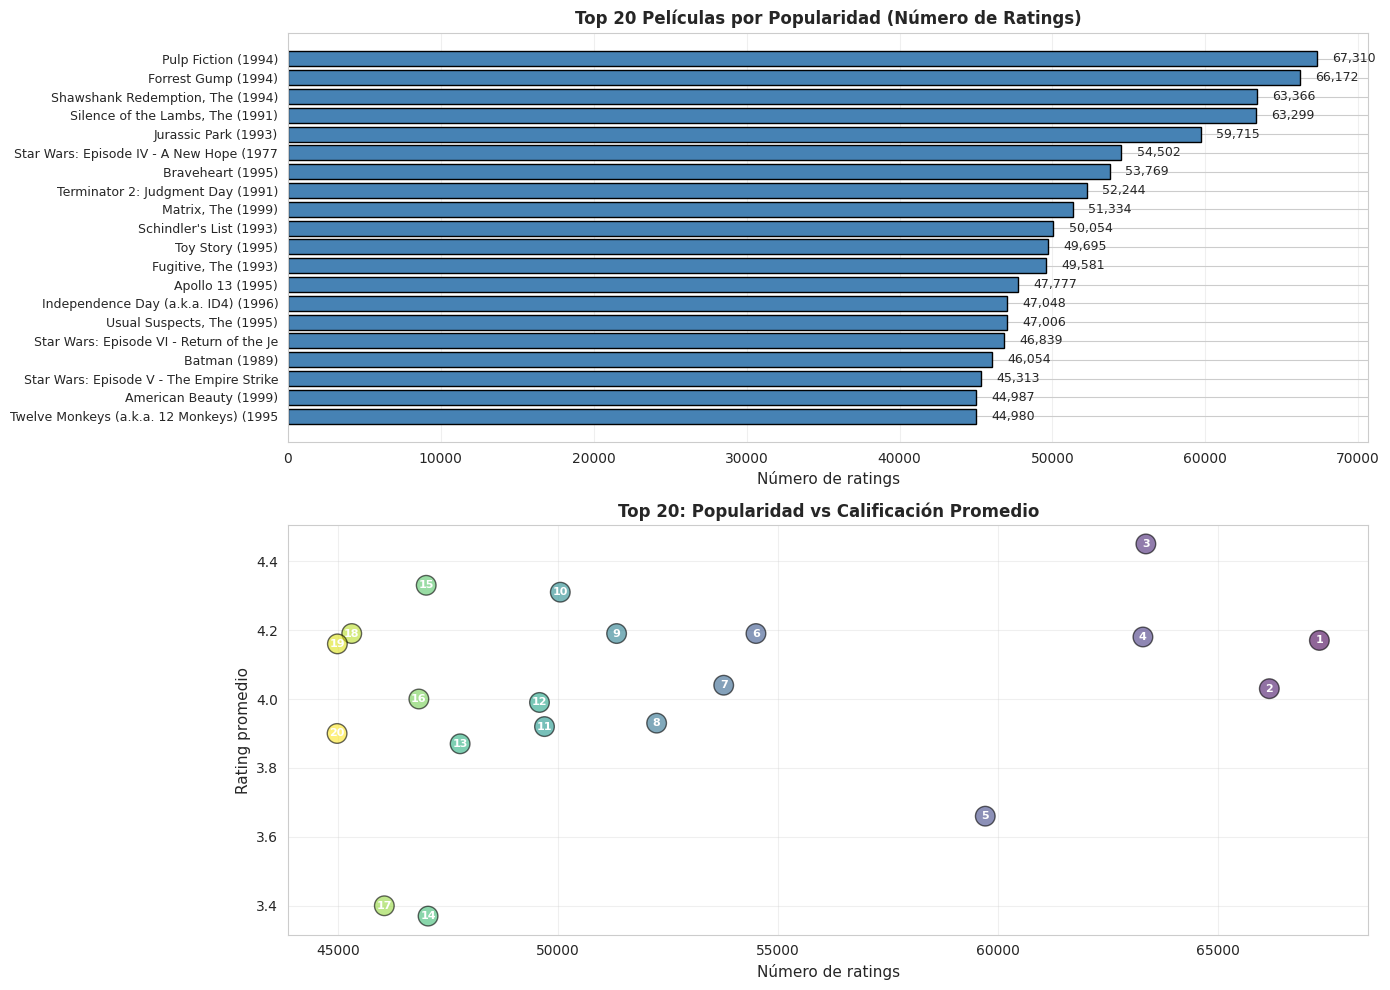

✓ Ranking de popularidad visualizado


In [ ]:
# Preparar datos para visualización
top_movies_df = top_movies_sql.toPandas()
top_movies_df['title'] = top_movies_df['title'].str[:40]  # Truncar títulos largos

# Crear gráficas
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1: Número de ratings (barras horizontales)
axes[0].barh(range(len(top_movies_df)), top_movies_df['num_ratings'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_movies_df)))
axes[0].set_yticklabels(top_movies_df['title'], fontsize=9)
axes[0].set_xlabel('Número de ratings', fontsize=11)
axes[0].set_title('Top 20 Películas por Popularidad (Número de Ratings)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(top_movies_df['num_ratings']):
    axes[0].text(v + 1000, i, f'{int(v):,}', va='center', fontsize=9)

# Gráfica 2: Rating promedio vs Número de ratings (scatter)
scatter = axes[1].scatter(top_movies_df['num_ratings'], 
                          top_movies_df['avg_rating'],
                          s=200, alpha=0.6, c=range(len(top_movies_df)), 
                          cmap='viridis', edgecolor='black', linewidth=1)
axes[1].set_xlabel('Número de ratings', fontsize=11)
axes[1].set_ylabel('Rating promedio', fontsize=11)
axes[1].set_title('Top 20: Popularidad vs Calificación Promedio', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Añadir etiquetas en los puntos
for idx, row in top_movies_df.iterrows():
    axes[1].annotate(str(idx+1), (row['num_ratings'], row['avg_rating']),
                     fontsize=8, ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

---

# PARTE III: SIMILITUD, MINHASHING Y LSH

## Introducción a la Parte III

En esta parte implementamos técnicas avanzadas para encontrar películas similares:

### Conceptos Clave

**1. Similitud de Jaccard:**

**2. MinHashing (Estimación de Jaccard):**

**3. Locality Sensitive Hashing (LSH):**

### Representaciones posibles

**Opción A - Usuarios:** Cada película = conjunto de usuarios que la calificaron positivamente

**Opción B - Tags:** Cada película = conjunto de tags asignados

**Opción C - Combinada:** Explorar ambas

---

## 3.1 Estrategia de Representación

En este proyecto usaremos **Opción A: Representación por Usuarios** porque:
- Los ratings binarios (like/dislike) dan conjuntos claros y bien definidos
- La densidad de usuarios es suficiente para encontrar patrones
- Es directamente aplicable a sistemas de recomendación colaborativos

---

## 3.2 Similitud Exacta vs Aproximada (MinHashing)

### Representación de películas como conjuntos de usuarios que las calificaron positivamente

In [ ]:
from pyspark.sql.functions import col, collect_set

print("CREANDO REPRESENTACIÓN POR USUARIOS\n")
print("=" * 70)

# 1. Filtrar solo ratings positivos
positive_ratings = ratings_binary.filter(col("binary_rating") == 1)

# 2.
# Hacemos el join inmediatamente después para tener el título disponible
movies_users = positive_ratings.groupBy("movieId").agg(
    collect_set("userId").alias("user_set")
).join(
    movies_dedupe.select("movieId", "title"),
    on="movieId",
    how="inner"
)

# 3. Mostrar ejemplos para verificar
print("Representación: Cada película como conjunto único de usuarios\n")
print("Ejemplos:")

# Usamos un limit pequeño para no sobrecargar el driver al recolectar
example_movies = movies_users.limit(5).collect()

for row in example_movies:
    # Ordenamos solo para visualización
    user_list = sorted(list(row['user_set']))[:10] 
    print(f"\nMovieId: {row['movieId']}")
    print(f"Title: {row['title']}")
    print(f"Usuarios (primeros 10): {user_list}")
    print(f"Total de usuarios únicos: {len(row['user_set'])}")

# 4. Registrar vista temporal
movies_users.createOrReplaceTempView("movies_users_view")

total_count = movies_users.count()
print(f"\n✓ Se crearon {total_count} representaciones de películas")

CREANDO REPRESENTACIÓN POR USUARIOS

Representación: Cada película como conjunto único de usuarios

Ejemplos:



MovieId: 31
Title: Dangerous Minds (1995)
Usuarios (primeros 10): [29, 42, 57, 60, 61, 127, 209, 279, 294, 298]
Total de usuarios únicos: 3967

MovieId: 65
Title: Bio-Dome (1996)
Usuarios (primeros 10): [204, 251, 422, 768, 850, 1099, 1281, 1505, 1539, 1540]
Total de usuarios únicos: 941

MovieId: 85
Title: Angels and Insects (1995)
Usuarios (primeros 10): [41, 208, 310, 324, 375, 443, 603, 685, 717, 741]
Total de usuarios únicos: 1509

MovieId: 137
Title: Man of the Year (1995)
Usuarios (primeros 10): [1667, 4009, 4201, 5292, 7054, 7273, 8580, 10321, 10732, 15302]
Total de usuarios únicos: 90

MovieId: 251
Title: Hunted, The (1995)
Usuarios (primeros 10): [461, 1021, 3202, 4706, 5314, 5494, 5640, 6266, 6314, 6460]
Total de usuarios únicos: 129



✓ Se crearon 22884 representaciones de películas


### Muestreo de la Representación

- Al ser demasiada data para procesar toda la matriz usuario-película, tomaremos una muestra representativa de películas para implementar la similitud de Jaccard y Minhashing.

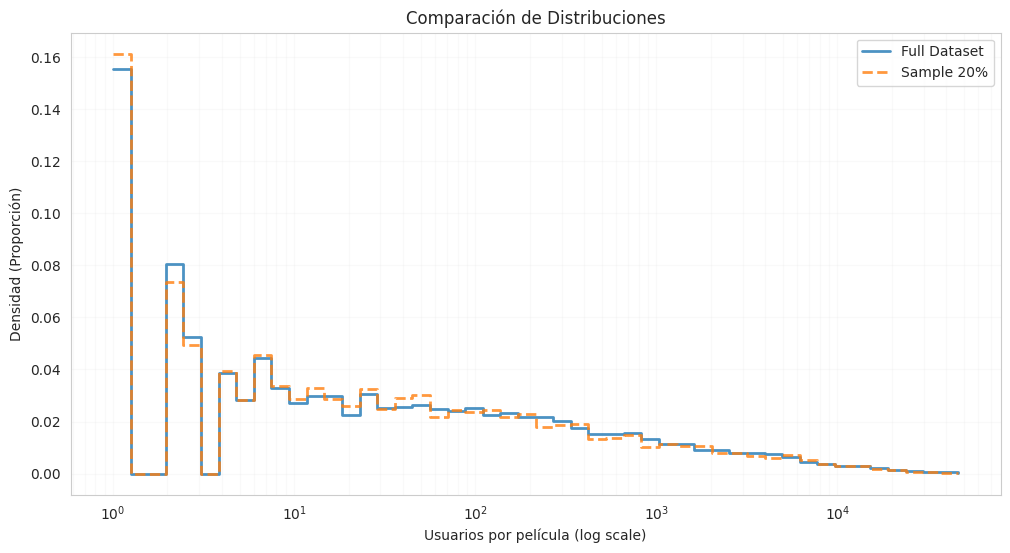

In [7]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import numpy as np
import builtins

full_dist = movies_users.select(F.size("user_set").alias("num_users"))
sample_df = movies_users.sample(False, 0.2, seed=42)
sample_dist = sample_df.select(F.size("user_set").alias("num_users"))

# 1. Obtener el rango global (Min y Max del dataset completo)
# Esto es necesario para definir bins que cubran ambos sets
stats = full_dist.select(
    F.min("num_users").alias("min"),
    F.max("num_users").alias("max")
).first()

global_min = builtins.max(1, stats["min"]) # Evitar 0 para la escala logarítmica
global_max = stats["max"]

# 2. Definir Bins fijos (usamos np.logspace para que se vean bien en escala log)
num_bins = 50
fixed_bins = np.logspace(np.log10(global_min), np.log10(global_max), num_bins)

# Convertir a lista para que Spark lo acepte
bins_list = fixed_bins.tolist()

# 3. Calcular histogramas con Bins predefinidos
def get_counts_fixed_bins(df, column, bins):
    # Al pasar una lista, Spark usa EXACTAMENTE esos bordes
    rdd = df.select(column).rdd.map(lambda x: x[0])
    _, counts = rdd.histogram(bins)
    return counts

full_counts = get_counts_fixed_bins(full_dist, "num_users", bins_list)
sample_counts = get_counts_fixed_bins(sample_dist, "num_users", bins_list)

# 4. Graficar
plt.figure(figsize=(12, 6))

# Normalización
full_density = np.array(full_counts) / builtins.sum(full_counts)
sample_density = np.array(sample_counts) / builtins.sum(sample_counts)

# Usamos step plot o baras alineadas
# El ancho de la barra en escala log varía, por eso un step plot suele ser más limpio
plt.step(fixed_bins[:-1], full_density, where='post', label="Full Dataset", alpha=0.8, lw=2)
plt.step(fixed_bins[:-1], sample_density, where='post', label="Sample 20%", alpha=0.8, lw=2, linestyle='--')

plt.xscale("log")
plt.xlabel("Usuarios por película (log scale)")
plt.ylabel("Densidad (Proporción)")
plt.title("Comparación de Distribuciones")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.1)

plt.show()

- Para poder saber si nuestro sampleo es representativo, comparamos la distribución del número de usuarios por película entre el dataset completo y el subconjunto muestreado (20%). Para esto, graficamos histogramas normalizados con bins alineados en escala logarítmica, como se observa en la figura ambas distribuciones presentan una alta superposición y mantienen la característica long-tail del dataset.

### Implementacion de similitud de Jaccard exacta

In [9]:
from pyspark.sql import functions as F

# 1. Preparar el DataFrame para el Self-Join
# Seleccionamos solo lo necesario para ahorrar memoria
df_to_join = sample_df.select("movieId", "title", "user_set")

# 2. Realizar el Self-Join para generar pares únicos
# La condición a.movieId < b.movieId evita duplicados (A,B y B,A) y compararse consigo mismo
pairs_df = df_to_join.alias("a").join(
    df_to_join.alias("b"),
    F.col("a.movieId") < F.col("b.movieId")
)

jaccard_pairs = []

# 3. Calcular Intersección, Unión y Jaccard usando funciones de arreglos
# Nota: Jaccard = |A ∩ B| / |A ∪ B|

intersection_expr = F.size(F.array_intersect(F.col("a.user_set"), F.col("b.user_set")))
union_expr = F.size(F.array_union(F.col("a.user_set"), F.col("b.user_set")))

jaccard_results = pairs_df.select(
    "*",  # Mantenemos las columnas que ya traía pairs_df (a y b)
    intersection_expr.alias("intersection_size"),
    union_expr.alias("union_size"),
    (intersection_expr / union_expr).alias("jaccard_sim")
)
# 4. Filtrar y obtener el Top 20
# Filtramos similitudes > 0 para evitar ruido
top_20_jaccard = jaccard_results.filter(F.col("jaccard_sim") > 0) \
    .select(
        F.col("a.title").alias("Movie_1"),
        F.col("b.title").alias("Movie_2"),
        F.round("jaccard_sim", 4).alias("Jaccard_Sim")
    ) \
    .orderBy(F.col("jaccard_sim").desc()) \
    .limit(20)

# 5. Mostrar resultados
print("\nTop 20 pares de películas más similares")
top_20_jaccard.show(truncate=False)


Top 20 pares de películas más similares


+--------------------------------------------------------------+--------------------------------------------------------------+-----------+
|Movie_1                                                       |Movie_2                                                       |Jaccard_Sim|
+--------------------------------------------------------------+--------------------------------------------------------------+-----------+
|Bomber (1982)                                                 |Rage (1972)                                                   |1.0        |
|Zero 2 (2010)                                                 |Park Avenue: Money, Power and the American Dream (2012)       |1.0        |
|Zero 2 (2010)                                                 |Hollywood and The Pentagon: A Dangerous Liaison (2003)        |1.0        |
|Paying the Price: Killing the Children of Iraq (2000)         |Park Avenue: Money, Power and the American Dream (2012)       |1.0        |
|Zero 2 (2010)      

### Implementación MinHashing

In [10]:
import random
import builtins
import time
import numpy as np
import pyspark.sql.functions as F
from collections import defaultdict

print("\n" + "="*70)
print("EVALUACIÓN MINHASH vs JACCARD (OPTIMIZADA Y VALIDADA)")
print("="*70 + "\n")

# ==============================
# 1. PERSISTENCIA DEL SAMPLEO
# ==============================
# Usamos el sample_df que ya validamos con el histograma
sample_df.cache() 

print("Recolectando datos del sampleo validado...")
# Traemos los datos al driver (Python local)
movies_sample = sample_df.collect()
print(f"Películas en el sample: {len(movies_sample)}")

# ==============================
# 2. PREPARACIÓN DE ESTRUCTURAS
# ==============================
movie_dict = {
    row["movieId"]: set(row["user_set"])
    for row in movies_sample
}
movie_ids = list(movie_dict.keys())

# ==============================
# 3. GENERACIÓN DE PARES ALEATORIOS
# ==============================
# Limitamos los pares para asegurar estabilidad y velocidad
MAX_PAIRS_EVAL = 2000000 
random.seed(42)
random.shuffle(movie_ids)

pairs = []
for i in range(len(movie_ids)):
    for j in range(i + 1, len(movie_ids)):
        pairs.append((movie_ids[i], movie_ids[j]))

print(f"Pares aleatorios generados para evaluación: {len(pairs)}")

# ==============================
# 4. CONFIGURACIÓN DE FUNCIONES HASH
# ==============================
K_VALUES = [10, 20, 50, 100, 200]
max_val = 2**31 - 1 # Mersenne prime para mejor distribución de hash

MAX_K = builtins.max(K_VALUES)
all_hash_funcs = [
    (random.randint(1, max_val), random.randint(0, max_val))
    for _ in range(MAX_K)
]

def compute_signature(users, hash_funcs):
    """Calcula la firma de Min-Hashing para un set de usuarios."""
    users_list = list(users)
    sig = []
    for a, b in hash_funcs:
        # Aplicamos la función hash: (a*x + b) % p
        m_hash = builtins.min((a * x + b) % max_val for x in users_list)
        sig.append(m_hash)
    return sig

# ==============================
# 5. EVALUACIÓN POR K
# ==============================
results = []
# Diccionario para trackear el error por película en el mejor k (usaremos el último)
movie_error_tracker = defaultdict(list)

for k in K_VALUES:
    print(f"\n>>> Evaluando k = {k}...")
    start_time = time.time()
    
    hash_funcs = all_hash_funcs[:k]
    
    # Pre-calcular firmas para este k
    signatures = {m_id: compute_signature(users, hash_funcs) 
                  for m_id, users in movie_dict.items()}
    
    errors = []
    
    for m1, m2 in pairs:
        # 1. Jaccard Exacto
        s1, s2 = movie_dict[m1], movie_dict[m2]
        inter = len(s1 & s2)
        union = len(s1 | s2)
        exact = inter / union if union > 0 else 0
        
        # 2. Min-Hash (Aproximado)
        sig1, sig2 = signatures[m1], signatures[m2]
        approx = builtins.sum(1 for i in range(k) if sig1[i] == sig2[i]) / k
        
        err = builtins.abs(approx - exact)
        errors.append(err)
        
        # Si es el k más alto, guardamos el error para el Top 20 final
        if k == builtins.max(K_VALUES):
            movie_error_tracker[m1].append(err)
            movie_error_tracker[m2].append(err)

    elapsed = time.time() - start_time
    mean_err = np.mean(errors)
    
    results.append({"k": k, "mean_error": mean_err, "time": elapsed})
    print(f" Error promedio: {mean_err:.4f} | Tiempo: {elapsed:.2f}s")

# Limpiar caché al finalizar
sample_df.unpersist()


EVALUACIÓN MINHASH vs JACCARD (OPTIMIZADA Y VALIDADA)

Recolectando datos del sampleo validado...


Películas en el sample: 4590
Pares aleatorios generados para evaluación: 10531755

>>> Evaluando k = 10...
 Error promedio: 0.0044 | Tiempo: 306.14s

>>> Evaluando k = 20...
 Error promedio: 0.0038 | Tiempo: 319.79s

>>> Evaluando k = 50...
 Error promedio: 0.0026 | Tiempo: 330.77s

>>> Evaluando k = 100...
 Error promedio: 0.0019 | Tiempo: 362.95s

>>> Evaluando k = 200...
 Error promedio: 0.0014 | Tiempo: 427.32s


DataFrame[movieId: int, user_set: array<int>, title: string]

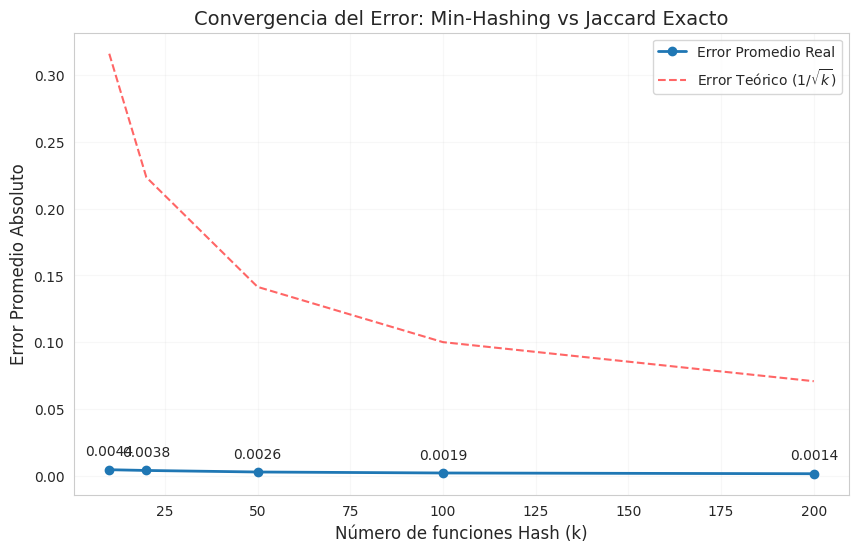

In [11]:
import matplotlib.pyplot as plt

# 1. Extraer datos de la lista de resultados
ks = [r['k'] for r in results]
mean_errors = [r['mean_error'] for r in results]

# 2. Calcular la curva teórica (1/sqrt(k)) para comparar
# La teoría dice que el error estándar es aproximadamente 1 / sqrt(k)
theoretical_errors = [1 / np.sqrt(k) for k in ks]

plt.figure(figsize=(10, 6))

# Graficar error real
plt.plot(ks, mean_errors, marker='o', linestyle='-', linewidth=2, label='Error Promedio Real')

# Graficar curva teórica
plt.plot(ks, theoretical_errors, marker='', linestyle='--', color='red', alpha=0.6, label='Error Teórico ($1/\sqrt{k}$)')

# Configuración de estética académica
plt.title("Convergencia del Error: Min-Hashing vs Jaccard Exacto", fontsize=14)
plt.xlabel("Número de funciones Hash (k)", fontsize=12)
plt.ylabel("Error Promedio Absoluto", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.legend()

# Opcional: Mostrar los valores de los puntos en el gráfico
for i, txt in enumerate(mean_errors):
    plt.annotate(f"{txt:.4f}", (ks[i], mean_errors[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

### Comparativa Jaccard exacto vs MinHash (Análisis de error y precisión)


COMPARATIVA: JACCARD EXACTO vs MINHASH

Número de pares evaluados: 2910392

Métricas de Error:
  • MAE:  0.0049
  • RMSE: 0.0076
  • Max:  0.1450

Correlación:
  • Pearson: 0.9775
  • P-value: 0.0000e+00


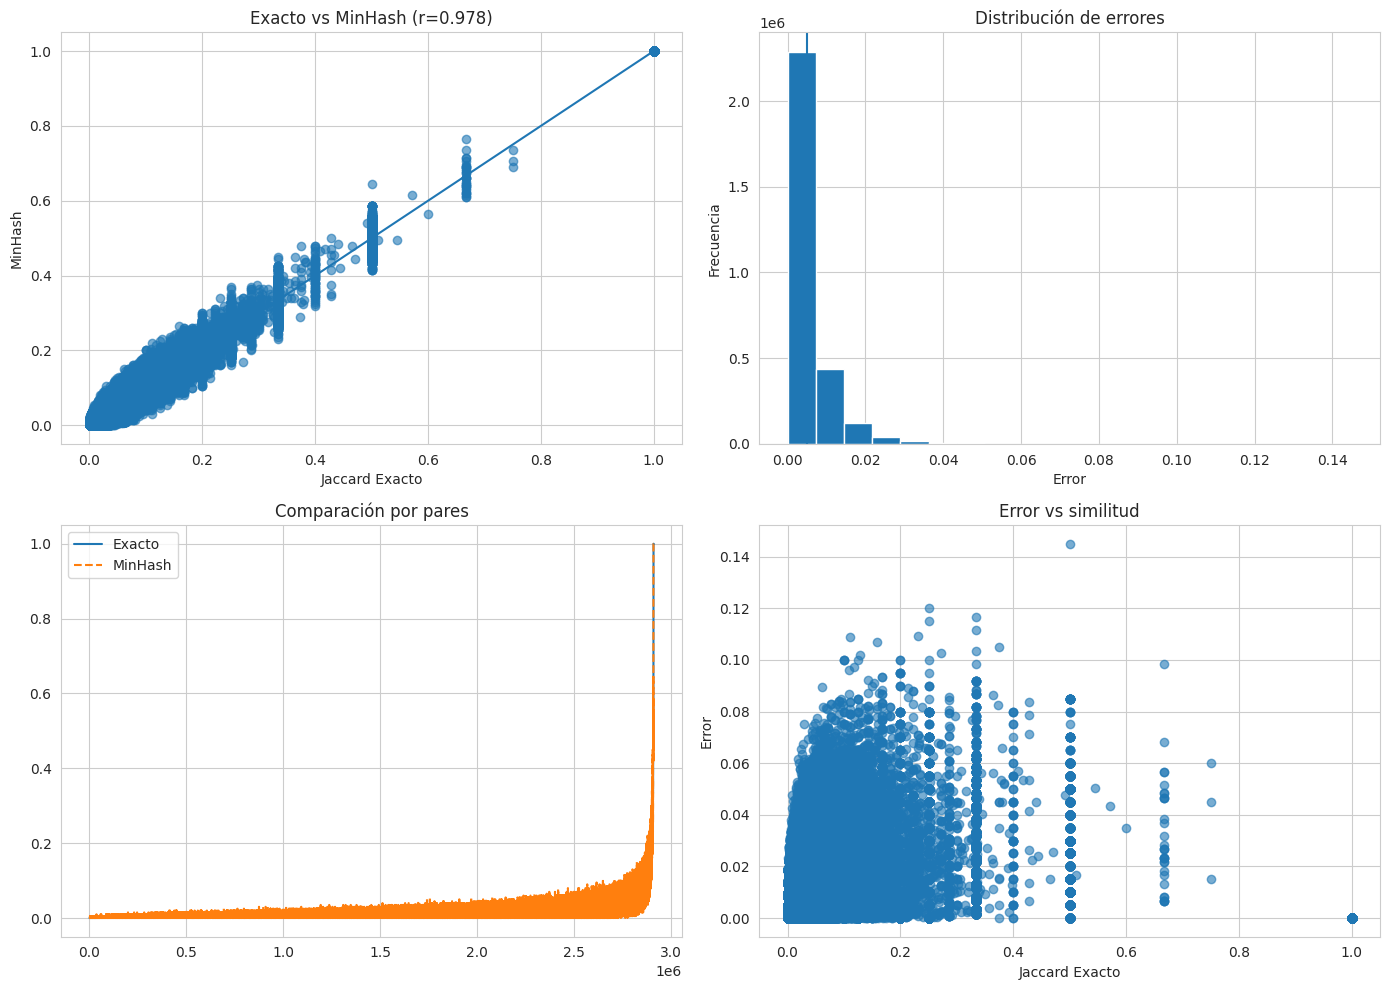

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import builtins

print("\nCOMPARATIVA: JACCARD EXACTO vs MINHASH\n")
print("=" * 70)

minhash_pairs = []

for m1, m2 in pairs:
    sig1 = signatures[m1]
    sig2 = signatures[m2]

    approx = builtins.sum(1 for i in range(k) if sig1[i] == sig2[i]) / k

    s1, s2 = movie_dict[m1], movie_dict[m2]
    inter = len(s1 & s2)
    union = len(s1 | s2)
    exact = inter / union if union > 0 else 0

    minhash_pairs.append({
        "movie1": m1,
        "movie2": m2,
        "minhash_sim": approx,
        "exact_sim": exact,
        "error": builtins.abs(approx - exact)
    })

valid_pairs = [
    p for p in minhash_pairs
    if p['exact_sim'] > 0 and p['minhash_sim'] >= 0
]

if len(valid_pairs) > 0:

    errors = [builtins.abs(p['error']) for p in valid_pairs]
    exact_sims = [p['exact_sim'] for p in valid_pairs]
    minhash_sims = [p['minhash_sim'] for p in valid_pairs]

    # ==============================
    # MÉTRICAS
    # ==============================
    mae = np.mean(errors)
    rmse = np.sqrt(np.mean([e**2 for e in errors]))
    max_error = np.max(errors)

    if len(valid_pairs) > 1:
        pearson_corr, pearson_pval = pearsonr(exact_sims, minhash_sims)
    else:
        pearson_corr, pearson_pval = 0, 1

    print(f"Número de pares evaluados: {len(valid_pairs)}")

    print("\nMétricas de Error:")
    print(f"  • MAE:  {mae:.4f}")
    print(f"  • RMSE: {rmse:.4f}")
    print(f"  • Max:  {max_error:.4f}")

    print("\nCorrelación:")
    print(f"  • Pearson: {pearson_corr:.4f}")
    print(f"  • P-value: {pearson_pval:.4e}")

    # ==============================
    # GRÁFICAS
    # ==============================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Scatter Exacto vs MinHash
    axes[0, 0].scatter(exact_sims, minhash_sims, alpha=0.6)
    axes[0, 0].plot([0, 1], [0, 1])
    axes[0, 0].set_xlabel('Jaccard Exacto')
    axes[0, 0].set_ylabel('MinHash')
    axes[0, 0].set_title(f'Exacto vs MinHash (r={pearson_corr:.3f})')
    axes[0, 0].grid(True)

    # 2. Histograma de errores
    axes[0, 1].hist(errors, bins=20)
    axes[0, 1].axvline(mae)
    axes[0, 1].set_xlabel('Error')
    axes[0, 1].set_ylabel('Frecuencia')
    axes[0, 1].set_title('Distribución de errores')

    # 3. Comparación ordenada
    sorted_idx = np.argsort(exact_sims)

    axes[1, 0].plot(np.array(exact_sims)[sorted_idx], label="Exacto")
    axes[1, 0].plot(np.array(minhash_sims)[sorted_idx], linestyle="--", label="MinHash")
    axes[1, 0].set_title("Comparación por pares")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # 4. Error vs similitud
    axes[1, 1].scatter(exact_sims, errors, alpha=0.6)
    axes[1, 1].set_xlabel("Jaccard Exacto")
    axes[1, 1].set_ylabel("Error")
    axes[1, 1].set_title("Error vs similitud")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

else:
    print("⚠ No hay pares válidos para comparar")

---

## 3.3 Locality Sensitive Hashing (LSH)

### Implementación Manual LSH

In [ ]:
from collections import defaultdict
from itertools import combinations
import builtins

# ==============================
# 1. FUNCIÓN LSH
# ==============================

def lsh_candidates(signatures, b, r):
    """
    signatures: dict {movieId: [signature]}
    b: número de bandas
    r: filas por banda
    """
    bands = [defaultdict(list) for _ in range(b)]

    for doc_id, sig in signatures.items():
        for band_idx in range(b):
            start = band_idx * r
            end = start + r
            band_key = tuple(sig[start:end])
            bands[band_idx][band_key].append(doc_id)

    candidates = set()

    for band in bands:
        for bucket in band.values():
            if len(bucket) > 1:
                for m1, m2 in combinations(bucket, 2):
                    candidates.add(tuple(sorted((m1, m2))))

    return candidates


# ==============================
# 2. CONFIGURACIÓN
# ==============================

LSH_CONFIGURATIONS = [
    (10, 20),
    (25, 8),
    (40, 5),
    (50, 4),
    (100, 2)
]
LSH_REAL_THRESHOLD = 0.3

k = builtins.max(K_VALUES)  # mismo k usado en MinHash

print(f"Total hashes (k): {k}")
print(f"Threshold real (Jaccard): {LSH_REAL_THRESHOLD}\n")

# ==============================
# 4. GROUND TRUTH
# ==============================

ground_truth_pos = set()

for m1, m2 in pairs:
    s1, s2 = movie_dict[m1], movie_dict[m2]
    inter = len(s1 & s2)
    union = len(s1 | s2)

    sim = inter / union if union > 0 else 0

    if sim >= LSH_REAL_THRESHOLD:
        ground_truth_pos.add(tuple(sorted((m1, m2))))

print(f"Pares realmente similares (ground truth): {len(ground_truth_pos)}\n")

# ==============================
# 5. EVALUAR CONFIGURACIONES
# ==============================

lsh_results = {}

for b, r in LSH_CONFIGURATIONS:

    if b * r != k:
        print(f"Saltando (b={b}, r={r}) → no cumple b*r=k")
        continue

    print(f"\nConfiguración (b={b}, r={r})")

    # Umbral teórico LSH
    threshold = (1.0 / b) ** (1.0 / r)

    # Candidatos
    candidates = lsh_candidates(signatures, b, r)

    predicted_pos = set(candidates)

    # ==============================
    # 6. MÉTRICAS
    # ==============================

    TP = len(predicted_pos & ground_truth_pos)
    FP = len(predicted_pos - ground_truth_pos)
    FN = len(ground_truth_pos - predicted_pos)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    lsh_results[(b, r)] = {
        "threshold": threshold,
        "candidates": len(candidates),
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print(f"  Umbral teórico: {threshold:.4f}")
    print(f"  Candidatos:     {len(candidates)}")
    print(f"  TP: {TP} | FP: {FP} | FN: {FN}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")


# ==============================
# 7. MEJOR CONFIGURACIÓN
# ==============================

best_config = builtins.max(lsh_results.items(), key=lambda x: x[1]["f1"])

print("\n" + "="*70)
print("MEJOR CONFIGURACIÓN LSH")
print("="*70)

(b, r), metrics = best_config

print(f"(b={b}, r={r})")
print(f"F1-score:  {metrics['f1']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"Candidatos: {metrics['candidates']}")

Total hashes (k): 200
Threshold real (Jaccard): 0.3

Pares realmente similares (ground truth): 6006


Configuración (b=10, r=20)
  Umbral teórico: 0.8913
  Candidatos:     1724
  TP: 1724 | FP: 0 | FN: 4282
  Precision: 1.0000
  Recall:    0.2870
  F1-score:  0.4461

Configuración (b=25, r=8)
  Umbral teórico: 0.6687
  Candidatos:     1843
  TP: 1843 | FP: 0 | FN: 4163
  Precision: 1.0000
  Recall:    0.3069
  F1-score:  0.4696

Configuración (b=40, r=5)
  Umbral teórico: 0.4782
  Candidatos:     3619
  TP: 3439 | FP: 180 | FN: 2567
  Precision: 0.9503
  Recall:    0.5726
  F1-score:  0.7146

Configuración (b=50, r=4)
  Umbral teórico: 0.3761
  Candidatos:     5843
  TP: 4677 | FP: 1166 | FN: 1329
  Precision: 0.8004
  Recall:    0.7787
  F1-score:  0.7894

Configuración (b=100, r=2)
  Umbral teórico: 0.1000
  Candidatos:     118836
  TP: 6006 | FP: 112830 | FN: 0
  Precision: 0.0505
  Recall:    1.0000
  F1-score:  0.0962

MEJOR CONFIGURACIÓN LSH
(b=50, r=4)
F1-score:  0.7894
Precisio

### Implementacion de Spark MLlib LSH

In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import MinHashLSH
import pyspark.sql.functions as SF
from pyspark.storagelevel import StorageLevel

# Asumiendo que estas variables ya están definidas en tu entorno
SPARK_LSH_NUM_HASH_TABLES = 20
LSH_REAL_THRESHOLD = 0.3
SPARK_APPROX_DISTANCE_THRESHOLD = 1.0 - LSH_REAL_THRESHOLD

print("="*70)
print("1) Construcción de features (sin UDF Python)")
print("="*70)

num_hash_tables = SPARK_LSH_NUM_HASH_TABLES

# Traemos la data al Driver asegurándonos de filtrar conjuntos vacíos
sample_movies_list = sample_df.filter(SF.size("user_set") > 0).collect()

# Universo de usuarios
all_users = sorted({u for movie in sample_movies_list for u in movie["user_set"]})
user_to_idx = {u: i for i, u in enumerate(all_users)}
vector_dim = len(all_users)

# Crear directamente vectores dispersos en Python y pasarlos a Spark
rows = []
for movie in sample_movies_list:
    movie_id = int(movie["movieId"])
    user_set = movie["user_set"] or []
    idx = sorted({user_to_idx[u] for u in user_set if u in user_to_idx})
    
    # Verificación de seguridad para evitar vectores vacíos en LSH
    if len(idx) > 0:
        features = Vectors.sparse(vector_dim, idx, [1.0] * len(idx))
        rows.append((movie_id, features))

df = spark.createDataFrame(rows, ["movieId", "features"]).repartition(8).persist(StorageLevel.MEMORY_AND_DISK)
_ = df.count()  # materializar cache

print("Schema final para LSH:")
df.printSchema()

# ==============================
# 2) Entrenamiento LSH
# ==============================
print("\n" + "="*70)
print("2) Entrenamiento LSH")
print("="*70)

lsh = MinHashLSH(
    inputCol="features",
    outputCol="hashes",
    numHashTables=num_hash_tables
)
model = lsh.fit(df)
print(f"✓ Modelo MinHashLSH entrenado correctamente (numHashTables={num_hash_tables})")

# ==============================
# 3) Comparación LSH vs Jaccard real (Spark-Native)
# ==============================
print("\n" + "="*70)
print("3) Comparación LSH vs Jaccard real")
print("="*70)

threshold_distance = SPARK_APPROX_DISTANCE_THRESHOLD
real_threshold = LSH_REAL_THRESHOLD

# Predichos por LSH
similar_pairs = model.approxSimilarityJoin(
    df, df,
    threshold=threshold_distance,
    distCol="dist"
)

predicted = (
    similar_pairs
    .select(
        SF.least(SF.col("datasetA.movieId"), SF.col("datasetB.movieId")).alias("id1"),
        SF.greatest(SF.col("datasetA.movieId"), SF.col("datasetB.movieId")).alias("id2"),
        (SF.lit(1.0) - SF.col("dist")).alias("jaccard_aprox")
    )
    .filter(SF.col("id1") < SF.col("id2"))
    .dropDuplicates(["id1", "id2"])
)

# Ground truth (Adaptado para usar jaccard_results directamente)
ground_truth = (
    jaccard_results.select(
        SF.least(SF.col("a.movieId"), SF.col("b.movieId")).alias("id1"),
        SF.greatest(SF.col("a.movieId"), SF.col("b.movieId")).alias("id2"),
        SF.col("jaccard_sim").alias("jaccard_real")
    ).dropDuplicates(["id1", "id2"])
)

predicted_pos = predicted.select(
    SF.col("id1"), 
    SF.col("id2"), 
    SF.lit(1).alias("pred")
)

ground_truth_pos = ground_truth.filter(SF.col("jaccard_real") >= real_threshold).select(
    SF.col("id1"), 
    SF.col("id2"), 
    SF.lit(1).alias("gt")
)

# TP/FP/FN en una sola pasada
conf = (
    predicted_pos.join(ground_truth_pos, ["id1", "id2"], "full_outer")
    .na.fill(0, ["pred", "gt"])
    .agg(
        SF.sum(SF.expr("CASE WHEN pred=1 AND gt=1 THEN 1 ELSE 0 END")).alias("tp"),
        SF.sum(SF.expr("CASE WHEN pred=1 AND gt=0 THEN 1 ELSE 0 END")).alias("fp"),
        SF.sum(SF.expr("CASE WHEN pred=0 AND gt=1 THEN 1 ELSE 0 END")).alias("fn")
    )
    .first()
)

tp = int(conf["tp"] or 0)
fp = int(conf["fp"] or 0)
fn = int(conf["fn"] or 0)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# Error numérico aprox vs real
error_expr = SF.col("jaccard_aprox") - SF.col("jaccard_real")

comparison = predicted.join(ground_truth, ["id1", "id2"], "inner").select(
    "*",  # Mantenemos todas las columnas resultantes del join
    SF.abs(error_expr).alias("abs_error"),
    SF.pow(error_expr, 2).alias("sq_error")
)
error_stats = comparison.agg(
    SF.count("*").alias("n_common_pairs"),
    SF.avg("abs_error").alias("mae"),
    SF.sqrt(SF.avg("sq_error")).alias("rmse")
).first()

print("\n=== COMPARACIÓN CONTRA JACCARD REAL ===")
print(f"Threshold real (sim): {real_threshold}")
print(f"Threshold LSH (dist): {threshold_distance}")
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Pares en común (para error): {error_stats['n_common_pairs'] or 0}")
print(f"MAE (sim):  {error_stats['mae'] if error_stats['mae'] is not None else 0.0:.4f}")
print(f"RMSE (sim): {error_stats['rmse'] if error_stats['rmse'] is not None else 0.0:.4f}")


# Limpieza de cache
comparison.unpersist(blocking=False) if comparison.is_cached else None
df.unpersist(blocking=False)

1) Construcción de features (sin UDF Python)


Schema final para LSH:
root
 |-- movieId: long (nullable = true)
 |-- features: vector (nullable = true)


2) Entrenamiento LSH
✓ Modelo MinHashLSH entrenado correctamente (numHashTables=20)

3) Comparación LSH vs Jaccard real



=== COMPARACIÓN CONTRA JACCARD REAL ===
Threshold real (sim): 0.3
Threshold LSH (dist): 0.7
TP: 6460
FP: 0
FN: 22
Precision: 1.0000
Recall:    0.9966
F1-score:  0.9983
Pares en común (para error): 6460
MAE (sim):  0.0000
RMSE (sim): 0.0000


DataFrame[movieId: bigint, features: vector]

### Paso 6: Visualización de resultados LSH - Trade-offs

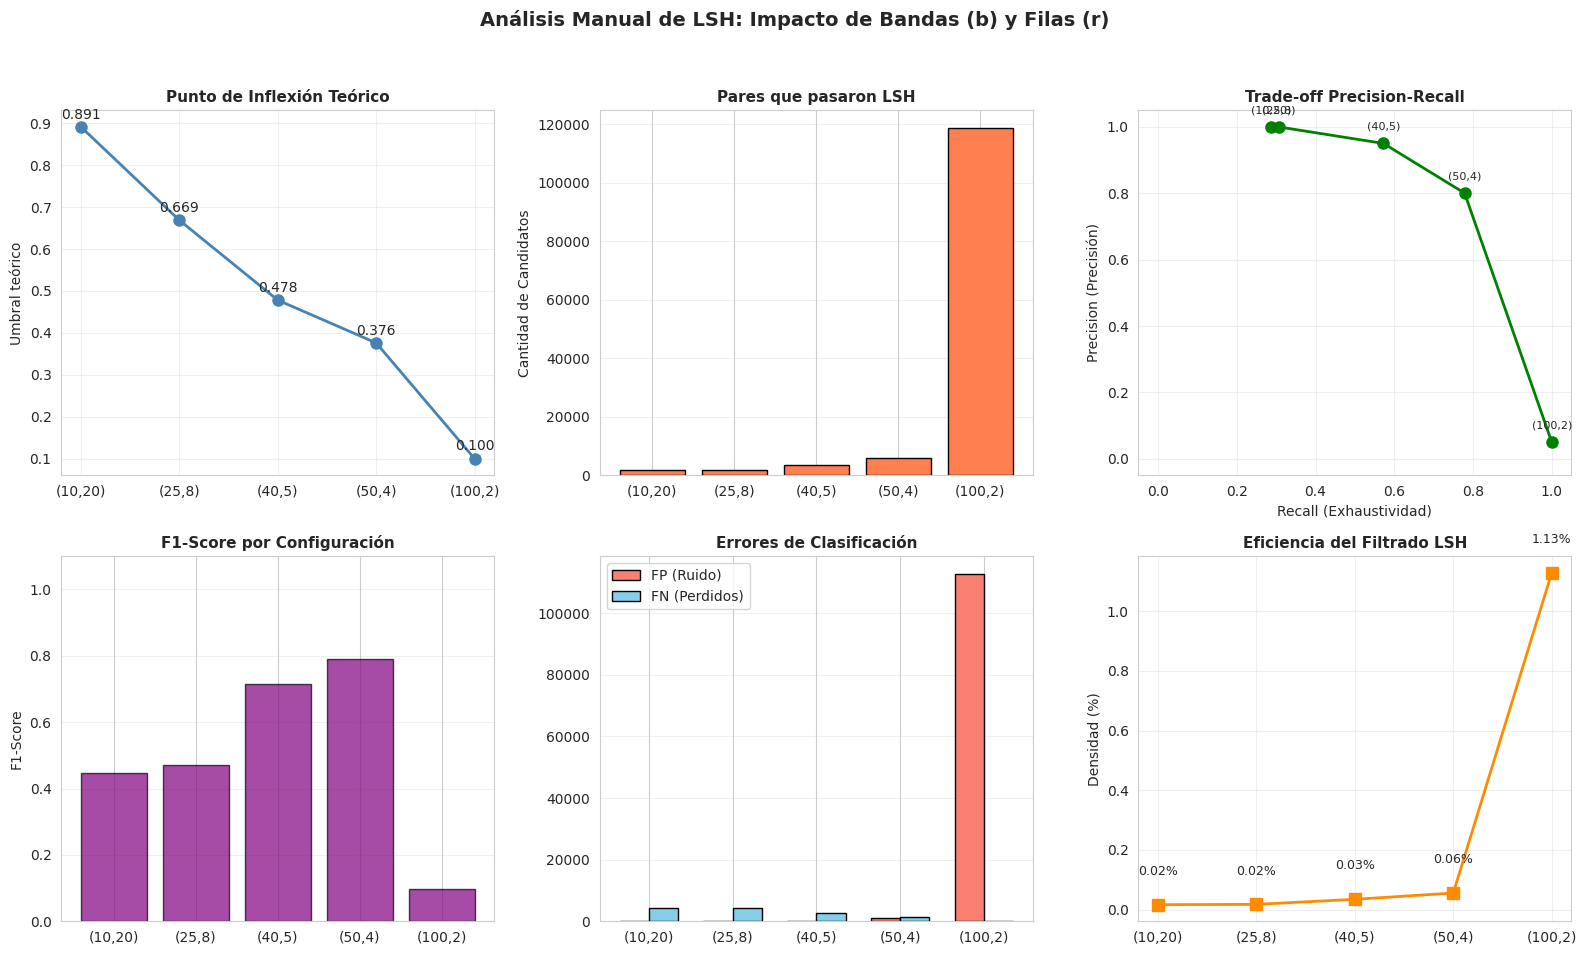

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 1. PREPARAR DATOS DESDE LSH_RESULTS (MANUAL)
# =========================================

# Usamos las configuraciones definidas en tu bloque anterior
LSH_CONFIGURATIONS = [
    (10, 20),
    (25, 8),
    (40, 5),
    (50, 4),
    (100, 2)
]

configs_labels = [f"({b},{r})" for b, r in LSH_CONFIGURATIONS]

# Extraemos métricas del diccionario lsh_results
thresholds = [lsh_results[conf]['threshold'] for conf in LSH_CONFIGURATIONS]
num_candidates = [lsh_results[conf]['candidates'] for conf in LSH_CONFIGURATIONS]
precisions = [lsh_results[conf]['precision'] for conf in LSH_CONFIGURATIONS]
recalls = [lsh_results[conf]['recall'] for conf in LSH_CONFIGURATIONS]
f1_scores = [lsh_results[conf]['f1'] for conf in LSH_CONFIGURATIONS]
fps = [lsh_results[conf]['FP'] for conf in LSH_CONFIGURATIONS] # Nota: Keys en mayúscula
fns = [lsh_results[conf]['FN'] for conf in LSH_CONFIGURATIONS]

# Cálculo de densidad (Total de películas en el sample para pares posibles)
# N * (N-1) / 2
n_movies = len(movie_dict)
total_possible_pairs = n_movies * (n_movies - 1) / 2

# =========================================
# 2. GENERACIÓN DE GRÁFICAS
# =========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis Manual de LSH: Impacto de Bandas (b) y Filas (r)', fontsize=14, fontweight='bold')

# 1. Umbral de similitud teórica (t ≈ (1/b)^(1/r))
axes[0, 0].plot(range(len(LSH_CONFIGURATIONS)), thresholds, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xticks(range(len(LSH_CONFIGURATIONS)))
axes[0, 0].set_xticklabels(configs_labels)
axes[0, 0].set_ylabel('Umbral teórico')
axes[0, 0].set_title('Punto de Inflexión Teórico', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(thresholds):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# 2. Número de pares candidatos (Efecto del filtrado)
axes[0, 1].bar(range(len(LSH_CONFIGURATIONS)), num_candidates, color='coral', edgecolor='black')
axes[0, 1].set_xticks(range(len(LSH_CONFIGURATIONS)))
axes[0, 1].set_xticklabels(configs_labels)
axes[0, 1].set_ylabel('Cantidad de Candidatos')
axes[0, 1].set_title('Pares que pasaron LSH', fontsize=11, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Precision-Recall Trade-off
axes[0, 2].plot(recalls, precisions, 'o-', linewidth=2, markersize=8, color='green')
axes[0, 2].set_xlabel('Recall (Exhaustividad)')
axes[0, 2].set_ylabel('Precision (Precisión)')
axes[0, 2].set_title('Trade-off Precision-Recall', fontsize=11, fontweight='bold')
axes[0, 2].set_xlim([-0.05, 1.05])
axes[0, 2].set_ylim([-0.05, 1.05])
axes[0, 2].grid(True, alpha=0.3)
for i, (r, p) in enumerate(zip(recalls, precisions)):
    axes[0, 2].annotate(configs_labels[i], (r, p), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

# 4. F1-score (Balance)
axes[1, 0].bar(range(len(LSH_CONFIGURATIONS)), f1_scores, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(LSH_CONFIGURATIONS)))
axes[1, 0].set_xticklabels(configs_labels)
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score por Configuración', fontsize=11, fontweight='bold')
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Falsos Positivos vs Falsos Negativos
x = np.arange(len(LSH_CONFIGURATIONS))
width = 0.35
axes[1, 1].bar(x - width/2, fps, width, label='FP (Ruido)', color='salmon', edgecolor='black')
axes[1, 1].bar(x + width/2, fns, width, label='FN (Perdidos)', color='skyblue', edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(configs_labels)
axes[1, 1].set_title('Errores de Clasificación', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Densidad de candidatos respecto al total
candidate_densities = [num / total_possible_pairs * 100 for num in num_candidates]
axes[1, 2].plot(range(len(LSH_CONFIGURATIONS)), candidate_densities, 's-', linewidth=2, markersize=8, color='darkorange')
axes[1, 2].set_xticks(range(len(LSH_CONFIGURATIONS)))
axes[1, 2].set_xticklabels(configs_labels)
axes[1, 2].set_ylabel('Densidad (%)')
axes[1, 2].set_title('Eficiencia del Filtrado LSH', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)
for i, v in enumerate(candidate_densities):
    axes[1, 2].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Paso 7: Análisis e Interpretación de Resultados

La elección de los parámetros b (número de bandas) y r (número de filas por banda) en LSH determina de manera directa tanto el umbral efectivo de similitud como el volumen de candidatos generados. Configuraciones con un mayor número de bandas y un menor número de filas por banda reducen el umbral de similitud, lo que incrementa significativamente la cantidad de pares candidatos y el recall. Sin embargo, este aumento se logra a costa de una disminución en la precisión, debido al incremento de falsos positivos. Por el contrario, configuraciones con menos bandas y más filas elevan el umbral de similitud, lo que produce un menor número de candidatos y una mayor precisión, pero reduce el recall al dejar de identificar algunos pares realmente similares. En consecuencia, se evidencia un trade-off claro entre precisión y recall, siendo necesario seleccionar una configuración balanceada en función de los objetivos específicos del sistema.

Por otro lado, la implementación manual permitió explorar de manera detallada distintas configuraciones de parámetros (b,r), evidenciando empíricamente este trade-off entre precisión y recall. En contraste, la implementación en Spark, basada en MinHashLSH con una configuración fija, presenta un comportamiento similar al de una configuración altamente permisiva del modelo manual. Esto se refleja en un recall elevado, acompañado de una precisión considerablemente baja debido al alto número de falsos positivos generados. Estos resultados sugieren que Spark prioriza la cobertura de pares potencialmente similares por encima de la exactitud, lo cual puede ser adecuado en escenarios donde es preferible no perder candidatos relevantes. No obstante, también pone de manifiesto la importancia del ajuste de parámetros para lograr un equilibrio adecuado entre precisión y recall según las necesidades del problema. 

# PARTE IV. REGLAS DE ASOCIACIÓN Y CONJUNTOS FRECUENTES

En esta sección aplicamos el algoritmo **FP-Growth** mediante Spark MLlib para descubrir patrones interesantes en las calificaciones de películas. El objetivo es identificar reglas de asociación que revelen relaciones entre películas: si los usuarios que califican positivamente una película tienden a calificar positivamente otra.

## Metodología
- **Datos**: Transacciones de usuarios con películas con calificación positiva (≥ 3.5 sobre 5)
- **Algoritmo**: FP-Growth (Frequent Pattern Growth) implementado en Spark
- **Métricas de evaluación**:
  - **Soporte**: Proporción de transacciones que contienen ambos items
  - **Confianza**: P(consecuente | antecedente)
  - **Lift**: Razón entre confianza observada y confianza esperada independientemente

In [ ]:
from pyspark.sql.functions import col, collect_list, size

print("\n" + "="*70)
print("ANÁLISIS DE PÉRDIDA DE USUARIOS")
print("="*70 + "\n")

# ==============================
# 1. Usuarios originales
# ==============================
total_users = ratings.select("userId").distinct().count()
print(f"Usuarios totales originales: {total_users:,}")

# ==============================
# 2. Usuarios con rating positivo
# ==============================
positive_ratings = ratings.filter(col("rating") >= 3.5)

users_positive = positive_ratings.select("userId").distinct().count()
print(f"Usuarios con ratings positivos: {users_positive:,}")
print(f"Usuarios perdidos aquí: {total_users - users_positive:,}")

# ==============================
# 3. Construir transacciones
# ==============================
transactions = positive_ratings.groupBy("userId").agg(
    collect_list(col("movieId")).alias("movies")
)

users_transactions = transactions.count()
print(f"\nUsuarios con transacciones: {users_transactions:,}")

# ==============================
# 4. Filtrar size > 1
# ==============================
filtered_min = transactions.filter(size(col("movies")) > 1)

users_min = filtered_min.count()
print(f"\nUsuarios con >1 película: {users_min:,}")
print(f"Usuarios eliminados (size <=1): {users_transactions - users_min:,}")

# ==============================
# 5. Filtrar size <= 50
# ==============================
filtered_max = filtered_min.filter(size(col("movies")) <= 220)

users_final = filtered_max.count()
print(f"\nUsuarios finales (<=50 películas): {users_final:,}")
print(f"Usuarios eliminados (size >50): {users_min - users_final:,}")

# ==============================
# 6. Resumen total
# ==============================
total_lost = total_users - users_final

print("\n" + "-"*70)
print("RESUMEN FINAL")
print("-"*70)
print(f"Usuarios iniciales: {total_users:,}")
print(f"Usuarios finales: {users_final:,}")
print(f"Total perdidos: {total_lost:,}")
print(f"Porcentaje perdido: {(total_lost / total_users)*100:.2f}%")


ANÁLISIS DE PÉRDIDA DE USUARIOS



Usuarios totales originales: 138,493


Usuarios con ratings positivos: 138,362
Usuarios perdidos aquí: 131



Usuarios con transacciones: 138,362



Usuarios con >1 película: 138,248
Usuarios eliminados (size <=1): 114



Usuarios finales (<=50 películas): 125,371
Usuarios eliminados (size >50): 12,877

----------------------------------------------------------------------
RESUMEN FINAL
----------------------------------------------------------------------
Usuarios iniciales: 138,493
Usuarios finales: 125,371
Total perdidos: 13,122
Porcentaje perdido: 9.47%


In [ ]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import col, collect_list, size, slice

print("\n" + "="*70)
print("FP-GROWTH OPTIMIZADO (ANTI-OOM)")
print("="*70 + "\n")

# ==============================
# 1. Parámetros SEGUROS
# ==============================
RATING_THRESHOLD = 3.5
MIN_SUPPORT = 0.03        # 🔥 clave (sube si falla)
MIN_CONFIDENCE = 0.1

# ==============================
# 2. Preparar transacciones
# ==============================
positive_movies_per_user = ratings.filter(
    col('rating') >= RATING_THRESHOLD
).groupBy('userId').agg(
    collect_list(col('movieId')).alias('movies')
)

# 🔥 FILTROS CRÍTICOS
positive_movies_per_user = positive_movies_per_user \
    .filter(size(col("movies")) > 1) \
    .filter(size(col("movies")) <= 220)   # evitar usuarios extremos

print(f"Transacciones: {positive_movies_per_user.count()}")

# ==============================
# 3. FP-Growth
# ==============================
fp = FPGrowth(
    itemsCol="movies",
    minSupport=MIN_SUPPORT,
    minConfidence=MIN_CONFIDENCE,
    numPartitions=4
)

model = fp.fit(positive_movies_per_user)

# ==============================
# 4. ITEMSETS (sin explotar RAM)
# ==============================
print("\nTop Itemsets Frecuentes:")
model.freqItemsets.limit(10).show(truncate=False)

# ==============================
# 5. REGLAS (sin orderBy global)
# ==============================
rules = model.associationRules

print("\nReglas (muestra):")
rules.limit(10).show(truncate=False)

# ==============================
# 6. LIFT (seguro)
# ==============================
from pyspark.sql.functions import explode

total_transactions = positive_movies_per_user.count()

# Soporte de items individuales en un solo select
item_support = model.freqItemsets \
    .filter(size(col("items")) == 1) \
    .select(
        col("items")[0].alias("item"),
        (col("freq") / total_transactions).alias("support_item")
    )
# calcular lift sin explotar memoria
rules_enriched = rules \
    .select("*", explode(col("consequent")).alias("consequent_item")) \
    .join(item_support, col("consequent_item") == col("item"), "left") \
    .select(
        "antecedent", 
        "consequent", 
        "confidence",
        (col("confidence") / col("support_item")).alias("lift"),
        (col("confidence") * col("support_item")).alias("support")
    )
print("\nReglas con LIFT (muestra):")
rules_enriched.select(
    "antecedent", "consequent", "confidence", "lift"
).limit(10).show(truncate=False)


FP-GROWTH OPTIMIZADO (ANTI-OOM)



Transacciones: 125371



Top Itemsets Frecuentes:


26/05/03 19:33:23 WARN Executor: Managed memory leak detected; size = 953872288 bytes, task 0.0 in stage 567.0 (TID 16361)


+--------------------+-----+
|items               |freq |
+--------------------+-----+
|[318]               |48203|
|[260]               |35942|
|[260, 318]          |16231|
|[260, 296]          |16213|
|[260, 296, 318]     |10550|
|[260, 593]          |15869|
|[260, 593, 318]     |10383|
|[260, 593, 296]     |10801|
|[260, 593, 296, 318]|7721 |
|[260, 356]          |14465|
+--------------------+-----+


Reglas (muestra):


+----------------------------+----------+------------------+------------------+--------------------+
|antecedent                  |consequent|confidence        |lift              |support             |
+----------------------------+----------+------------------+------------------+--------------------+
|[7153, 4993, 2571, 260, 318]|[1196]    |0.9043166898746767|3.939507548082911 |0.03626037919455057 |
|[7153, 4993, 2571, 260, 318]|[1210]    |0.772826735627611 |3.4525909800224213|0.030988027534278262|
|[7153, 4993, 2571, 260, 318]|[5952]    |0.9325641535707181|5.608851067273423 |0.037393017523988804|
|[1221, 608, 260]            |[858]     |0.9436758893280632|4.216758381899298 |0.030469566327141047|
|[4226, 5952, 2959, 296]     |[318]     |0.765758600119308 |1.9916586406563441|0.03071683244131418 |
|[4226, 5952, 2959, 296]     |[2571]    |0.8804931397892225|3.262065763253978 |0.03531917269543994 |
|[4226, 5952, 2959, 296]     |[4993]    |0.9220520978325711|4.962803999371798 |0.0369862248


Reglas con LIFT (muestra):


+-----------------------+----------+-------------------+------------------+
|antecedent             |consequent|confidence         |lift              |
+-----------------------+----------+-------------------+------------------+
|[50, 593, 318]         |[1]       |0.35952820804320024|1.5494812984044022|
|[593]                  |[1]       |0.28822447728665807|1.2421791317258717|
|[527, 260, 296]        |[1]       |0.46634615384615385|2.009841308141841 |
|[2571, 296, 318]       |[1]       |0.42327533444084986|1.8242162926842143|
|[110, 260, 318]        |[1]       |0.5072236937153864 |2.1860138090337475|
|[589, 593]             |[1]       |0.3697555429221148 |1.593558685860724 |
|[2571, 110]            |[1]       |0.41003843879361324|1.767168412168927 |
|[527, 260, 356]        |[1]       |0.5319119479440676 |2.292414328831066 |
|[4993, 1196, 2571, 260]|[1]       |0.463905325443787  |1.999321916679719 |
|[589, 50]              |[1]       |0.40098655422070173|1.7281569367206462|
+-----------

In [ ]:
from pyspark.sql.functions import col, explode, size

print("\n" + "="*70)
print("TOP 10 REGLAS RELEVANTES (con métricas)")
print("="*70 + "\n")

total_transactions = positive_movies_per_user.count()

# ==============================
# 1. Filtrar reglas relevantes
# ==============================
rules_filtered = rules_enriched.filter(
    (col("confidence") >= 0.2) &   # más estrictas
    (col("lift") > 1)              # asociación positiva real
)

# ==============================
# 2. Top 10 por LIFT (sin order global pesado)
# ==============================
top_rules = rules_filtered.sortWithinPartitions(
    col("lift").desc()
).limit(10)

# ==============================
# 3. Mostrar resultados
# ==============================
top_rules.select(
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift"
).show(truncate=False)


TOP 10 REGLAS RELEVANTES (con métricas)



+------------------------+----------+--------------------+------------------+------------------+
|antecedent              |consequent|support             |confidence        |lift              |
+------------------------+----------+--------------------+------------------+------------------+
|[6874, 7153, 4993, 2571]|[7438]    |0.0569472202815408  |0.7649769585253456|10.276001957278591|
|[6874, 4993, 2959]      |[7438]    |0.056720588419229244|0.7619325930255212|10.235106730976385|
|[6874, 7153, 5952]      |[7438]    |0.056602078025122175|0.7603406326034063|10.213721788291187|
|[6874, 2571, 296]       |[7438]    |0.056232425619909654|0.7553750597228858|10.147018816298928|
|[6874, 2959, 2571]      |[7438]    |0.05607134902222919 |0.7532113037893384|10.117952894821936|
|[7438, 2959, 2571]      |[6874]    |0.07951366625784662 |0.8876064333017976|9.90829900716585  |
|[7438, 7153, 2959]      |[6874]    |0.07947379621335701 |0.8871613663133098|9.903330750250731 |
|[7438, 2959, 296]       |[687

In [ ]:
from pyspark.sql.functions import col
import builtins

print("\n" + "="*70)
print("PASO 4: DETALLES DE LAS REGLAS PRINCIPALES")
print("="*70)

# ==============================
# 1. Convertir reglas a lista (seguro)
# ==============================
top_rules_list = top_rules.collect()  # solo 10 → OK

# ==============================
# 2. Diccionario movieId → title
# ==============================
movie_dict = {
    int(row["movieId"]): row["title"]
    for row in movies.select("movieId", "title").collect()
}

# ==============================
# 3. Mostrar reglas (bonito)
# ==============================
for idx, row in enumerate(top_rules_list[:5], 1):
    antecedent_ids = row["antecedent"]
    consequent_ids = row["consequent"]

    # Convertir IDs → títulos
    antecedent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in antecedent_ids]
    consequent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in consequent_ids]

    print(f"\n╔═ REGLA {idx} ═{'='*65}")
    print(f"║")
    print(f"║  SI usuario calificó positivamente:")
    for title in antecedent_titles:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  ENTONCES es probable que también calificó positivamente:")
    for title in consequent_titles:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  Métricas:")
    print(f"║    • Soporte:   {row['support']:.4f} ({row['support']*100:.2f}%)")
    print(f"║    • Confianza: {row['confidence']:.4f} ({row['confidence']*100:.2f}%)")
    print(f"║    • Lift:      {row['lift']:.4f}x")

    # Interpretación del lift
    if row['lift'] > 1.5:
        strength = "MUY FUERTE"
    elif row['lift'] > 1.2:
        strength = "FUERTE"
    elif row['lift'] > 1.0:
        strength = "MODERADA"
    else:
        strength = "DÉBIL"

    print(f"║    • Fuerza:    {strength}")
    print(f"╚{'='*71}")

# ==============================
# 4. Estadísticas generales (seguro)
# ==============================
print(f"\n{'='*70}")
print("ESTADÍSTICAS GENERALES DE REGLAS")
print("="*70)

# 🔥 IMPORTANTE: limitar para no romper memoria
all_rules = rules_with_lift.select(
    "support", "confidence", "lift"
).limit(1000).collect()

if all_rules:
    confidences = [float(r["confidence"]) for r in all_rules]
    lifts = [float(r["lift"]) for r in all_rules]
    supports = [float(r["support"]) for r in all_rules]

    print(f"Total de reglas analizadas: {len(all_rules)}")

    print(f"\nConfianza:")
    print(f"  Media:    {builtins.sum(confidences)/len(confidences):.4f}")
    print(f"  Mínima:   {builtins.min(confidences):.4f}")
    print(f"  Máxima:   {builtins.max(confidences):.4f}")

    print(f"\nLift:")
    print(f"  Media:    {builtins.sum(lifts)/len(lifts):.4f}")
    print(f"  Mínimo:   {builtins.min(lifts):.4f}")
    print(f"  Máximo:   {builtins.max(lifts):.4f}")

    print(f"\nSoporte:")
    print(f"  Media:    {builtins.sum(supports)/len(supports):.6f}")
    print(f"  Mínimo:   {builtins.min(supports):.6f}")
    print(f"  Máximo:   {builtins.max(supports):.6f}")
else:
    print("No hay reglas para mostrar")

print(f"\n{'='*70}\n")


PASO 4: DETALLES DE LAS REGLAS PRINCIPALES



╔═ REGLA 1 ═=================================================================
║
║  SI usuario calificó positivamente:
║    → Kill Bill: Vol. 1 (2003)
║    → Lord of the Rings: The Return of the King, The (2003)
║    → Lord of the Rings: The Fellowship of the Ring, The (2001)
║    → Matrix, The (1999)
║
║  ENTONCES es probable que también calificó positivamente:
║    → Kill Bill: Vol. 2 (2004)
║
║  Métricas:
║    • Soporte:   0.0569 (5.69%)
║    • Confianza: 0.7650 (76.50%)
║    • Lift:      10.2760x
║    • Fuerza:    MUY FUERTE
╚=======================================================================

╔═ REGLA 2 ═=================================================================
║
║  SI usuario calificó positivamente:
║    → Kill Bill: Vol. 1 (2003)
║    → Lord of the Rings: The Fellowship of the Ring, The (2001)
║    → Fight Club (1999)
║
║  ENTONCES es probable que también calificó positivamente:
║    → Kill Bill: Vol. 2 (2004)
║
║  Métricas:
║    • Soporte:   0.0567 (5.67%)
║    • Co

Total de reglas analizadas: 1000

Confianza:
  Media:    0.6204
  Mínima:   0.1937
  Máxima:   0.9700

Lift:
  Media:    2.8181
  Mínimo:   1.0329
  Máximo:   6.8891

Soporte:
  Media:    0.037776
  Mínimo:   0.030007
  Máximo:   0.117595




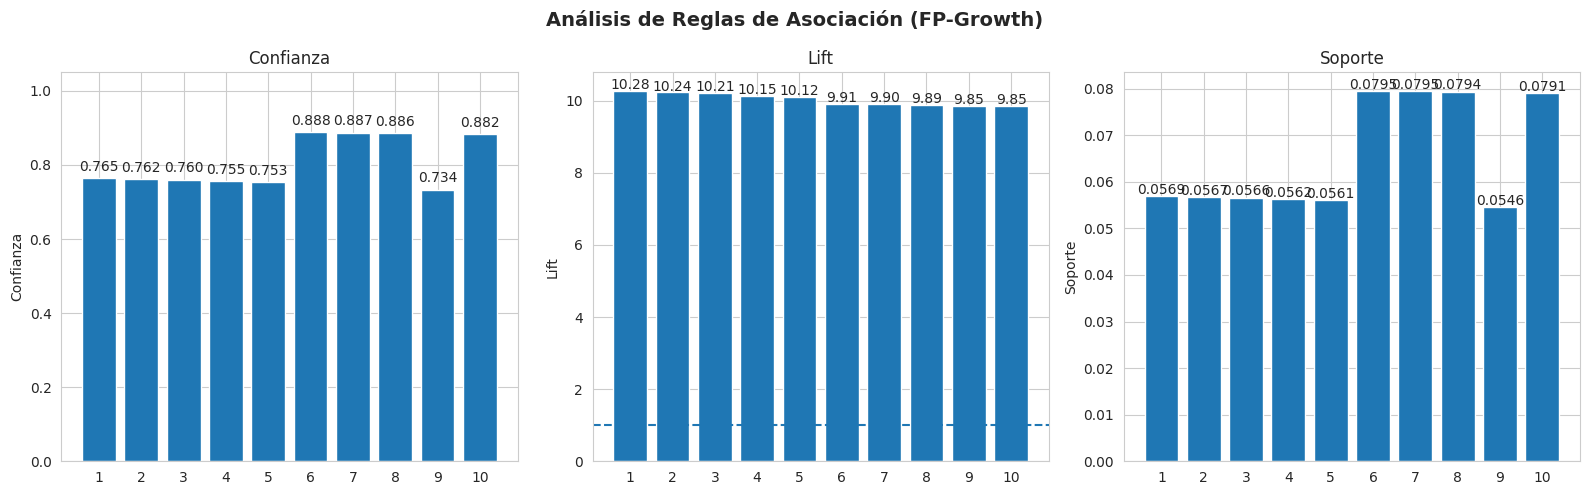

✓ Visualizaciones completadas



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import builtins

if top_rules_list:

    # ==============================
    # 1. Preparar datos
    # ==============================
    top_n = builtins.min(10, len(top_rules_list))

    rule_labels = []
    confidence_vals = []
    lift_vals = []
    support_vals = []

    for row in top_rules_list[:top_n]:
        antecedent_ids = row["antecedent"]
        consequent_ids = row["consequent"]

        # Convertir a títulos (solo el primero para etiqueta)
        ant_title = movie_dict.get(int(antecedent_ids[0]), str(antecedent_ids[0]))
        cons_title = movie_dict.get(int(consequent_ids[0]), str(consequent_ids[0]))

        rule_labels.append(f"{ant_title[:20]}\n→ {cons_title[:20]}")

        confidence_vals.append(float(row["confidence"]))
        lift_vals.append(float(row["lift"]))
        support_vals.append(float(row["support"]))

    # ==============================
    # 2. Crear gráficos
    # ==============================
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Reglas de Asociación (FP-Growth)', fontsize=14, fontweight='bold')

    x_pos = np.arange(len(rule_labels))

    # 🔹 Confianza
    axes[0].bar(x_pos, confidence_vals)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Confianza')
    axes[0].set_ylim([0, 1.05])

    for i, v in enumerate(confidence_vals):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

    # 🔹 Lift
    axes[1].bar(x_pos, lift_vals)
    axes[1].axhline(y=1.0, linestyle='--')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[1].set_ylabel('Lift')
    axes[1].set_title('Lift')

    for i, v in enumerate(lift_vals):
        axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

    # 🔹 Soporte
    axes[2].bar(x_pos, support_vals)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[2].set_ylabel('Soporte')
    axes[2].set_title('Soporte')

    for i, v in enumerate(support_vals):
        axes[2].text(i, v + 0.0005, f'{v:.4f}', ha='center')

    plt.tight_layout()
    plt.show()